In [ ]:
import pandas as pd
import glob
import re
import os
import seaborn as sns
import numpy as np
import scanpy as sc
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, ttest_ind

def extract_feature(adata, feature):

    ad_subset = adata[:, adata.var['feature_types']==feature]

    obs_names = adata.obs.index.tolist()
    var_names = ad_subset.var_names
    array = ad_subset.X.toarray()

    df = pd.DataFrame(
        array,
        index=obs_names,
        columns=var_names
    )

    return df

tumours = [
 'AT3',
 'AT4',
 'AT5',
 'AT6',
 'AT7',
 'AT9',
 'AT10',
 'AT11',
 'AT12',
 'AT13',
 'AT14',
 'AT15',
]

output_dir = '../../../data/Fig3/'

In [ ]:
# Load cell2loc output
sp_directory = '../../../data/GBM_LEAP_annotations/web_atlas/anndata/'
files = glob.glob(sp_directory+'*h5ad')

# load cell state spatial data
abundance_output = {}
niche_output = {}
histopath_output = {}

for tumour in tumours:
    tumour_files = [i for i in files if tumour+'-' in i]

    abundances = []
    niches = []
    histopaths = []
    
    for filepath in tumour_files:
        ad_tmp = sc.read_h5ad(filepath)
    
        abundances.append(extract_feature(ad_tmp, 'Cell state abundances'))
        niches.append(extract_feature(ad_tmp, 'Spatial niche abundances'))

        if 'Histopath annotation overlap' in set(ad_tmp.var['feature_types']):
            histopaths.append(extract_feature(ad_tmp, 'Histopath annotation overlap'))

    abundance_output[tumour] = pd.concat(abundances)
    niche_output[tumour] = pd.concat(niches)
    if len(histopaths)>0:
        histopath_output[tumour] = pd.concat(histopaths)

    del(ad_tmp)

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/annd

# Perinecrotic

In [ ]:
feature_threshold = 0.9

In [ ]:
# get input df
global_peri_summary = []

for tumour in histopath_output.keys():
    ct_df = abundance_output[tumour]
    histopath_df = histopath_output[tumour]

    ct_df = ct_df[ct_df.index.isin(histopath_df.index)]

    global_peri_summary.append(pd.concat([ct_df, histopath_df], axis=1))
global_peri_summary = pd.concat(global_peri_summary)

histopaths = ['Cellular tumor',
 'Hyperplastic blood vessels',
 'Infiltrating tumor (grey matter)',
 'Infiltrating tumor (white matter)',
 'Leading edge (grey matter)',
 'Leading edge (white matter)',
 'Microvascular proliferation',
 'Necrosis',
 'Perinecrotic zone',
 'Pseudopalisading cells around necrosis']

ct_list = [
'Hypoxic 1 (cell state)',
'Gliosis-like',
'AC-gliosis-like 1',
'AC progenitor-like 1',
'AC progenitor-like 2',
'OPC-NPC-like 1',
]

In [ ]:
peri_comparison_summary = []
for annotation in histopaths:

    # overlap
    composition = global_peri_summary[global_peri_summary[annotation]>=feature_threshold]
    composition = composition[ct_list].sum(skipna=True)
    composition = composition.divide(composition.sum())
    composition.name = 'proportion'
    composition = pd.DataFrame(composition).reset_index()
    composition['histopath_feature'] = annotation

    # correlation
    correlation = []
    for ct in ct_list:
        comp_df = global_peri_summary[[ct, annotation]].dropna()
        comp_df['feature_range'] = np.where(comp_df[annotation]>feature_threshold, 1, 0)

        if len(comp_df)>1:            
            corr, p_value = pointbiserialr(comp_df[annotation], comp_df[ct])
            correlation.append(pd.DataFrame({
                'index':ct,
                'histopath_feature':annotation,
                'r':corr,
                'p':p_value,
            }, index=[0]))
    correlation = pd.concat(correlation)

    peri_comparison_summary.append(pd.concat([
        composition.set_index(['index', 'histopath_feature']),
        correlation.set_index(['index', 'histopath_feature'])
    ], axis=1))
peri_comparison_summary = pd.concat(peri_comparison_summary).reset_index()

In [ ]:
peri_comparison_summary["index"] = pd.Categorical(
    peri_comparison_summary["index"],
    categories=ct_list,
    ordered=True
)

histopath_paper_order = [
 'Necrosis',
 'Pseudopalisading cells around necrosis',
 'Perinecrotic zone',
 'Cellular tumor'
]

peri_comparison_summary["histopath_feature"] = pd.Categorical(
    peri_comparison_summary["histopath_feature"],
    categories=histopath_paper_order,
    ordered=True
)

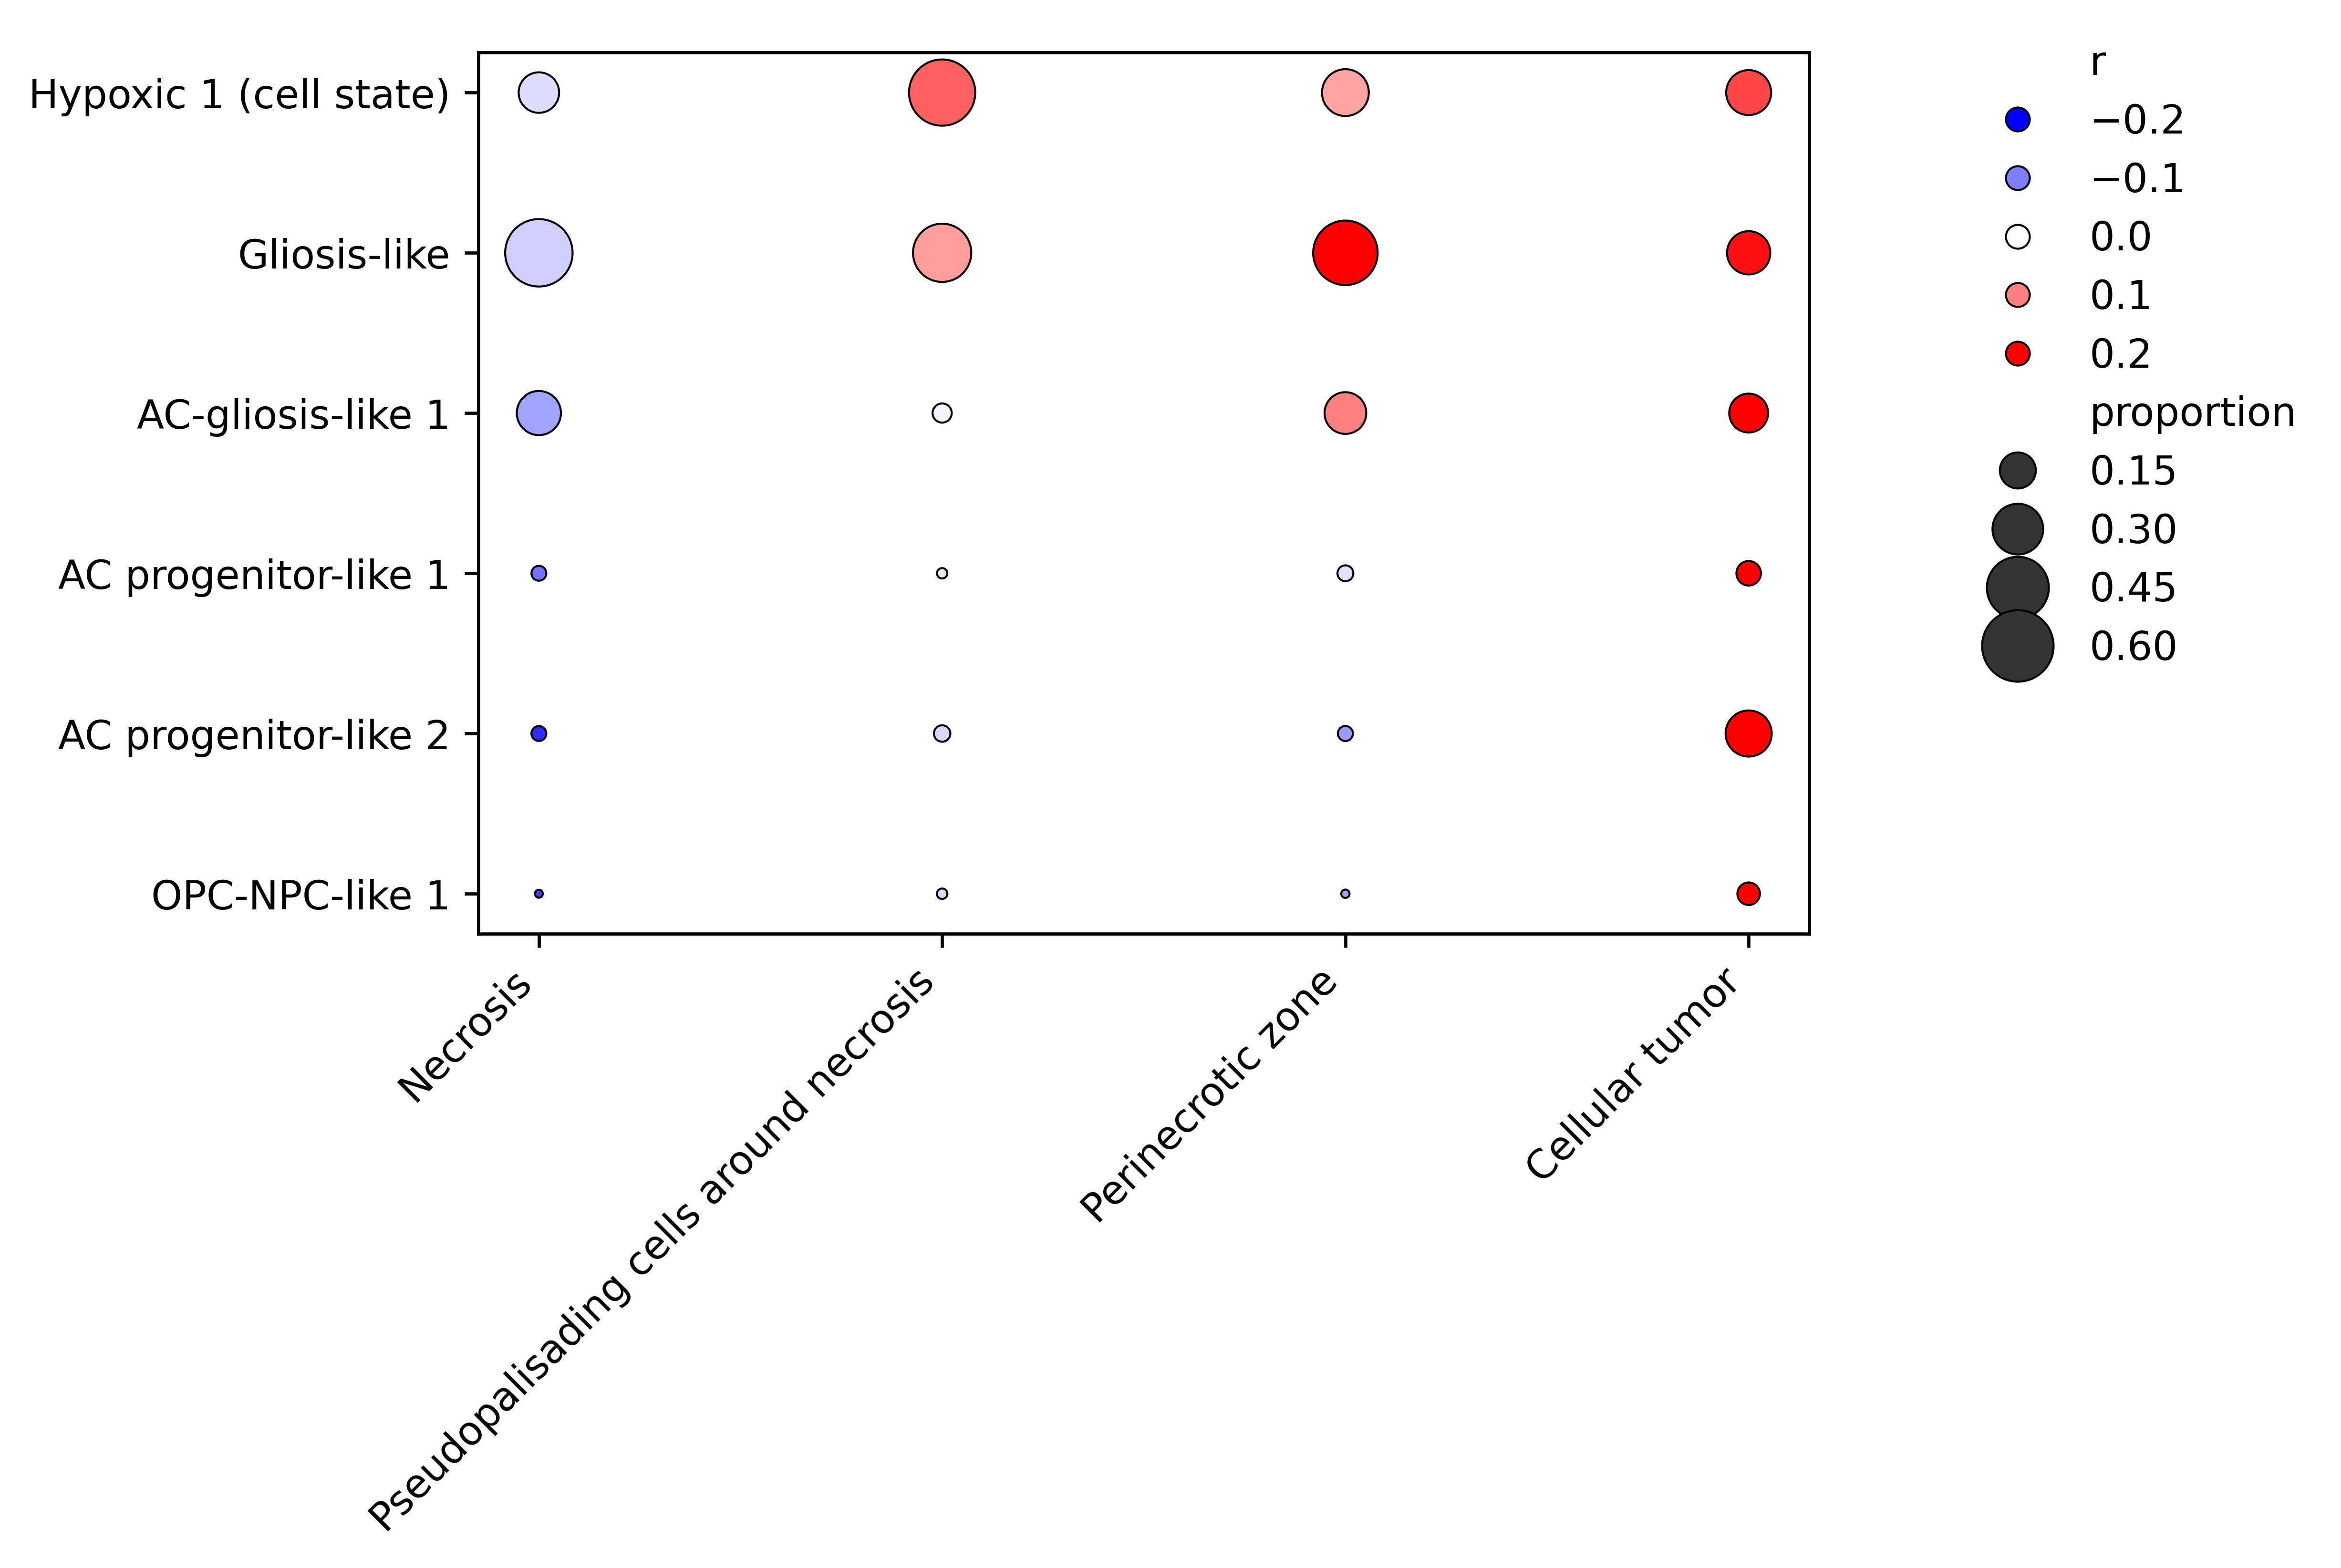

In [ ]:
f, ax = plt.subplots(figsize=(6, 4), sharey=True, dpi=600)
sns.scatterplot(data=peri_comparison_summary, x = 'histopath_feature', y = 'index',
                size = 'proportion', hue = 'r',
                sizes=(4, 400),
                hue_norm=(-0.2, 0.2),
                palette='bwr',
                edgecolor="black", linewidth=0.5
               )
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.1, 1.05), frameon=False)
plt.xlabel('')
plt.ylabel('')
plt.show()

In [ ]:
peri_comparison_summary.dropna().to_csv(os.path.join(output_dir, 'Fig3a.3'))